# TQQQ / SQQQ EMA5/EMA30 轮动策略回测

策略规则：

- 数据：Yahoo Finance 日线复权价格，起始日期 `2015-01-01`，结束到今天
- TQQQ 金叉：买入或切回 TQQQ
- TQQQ 死叉：卖出 TQQQ，尝试买入 SQQQ
- 持有 SQQQ 时，如果 SQQQ 自身死叉：卖出 SQQQ，先空仓
- 空仓时，如果 TQQQ 金叉：买入 TQQQ
- 成交假设：同时对比 next_open 和 close_after_signal 两种模式
- 手续费：每次买入或卖出固定 `$0.99`
- 仓位：满仓 TQQQ、满仓 SQQQ 或空仓，不加杠杆，不计滑点


In [2]:
# 如果 notebook 环境缺依赖，先运行下面这行：
# %pip install -q yfinance pandas matplotlib

from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [5]:
START_DATE = "2015-01-01"
END_DATE = date.today().isoformat()
INITIAL_CAPITAL = 10_000
COMMISSION_PER_TRADE = 0.99

FAST_WINDOW = 5
SLOW_WINDOW = 30
SYMBOLS = ["TQQQ", "SQQQ"]

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 下载并整理数据

In [6]:
raw = yf.download(
    SYMBOLS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise RuntimeError("没有下载到行情数据，请检查网络、yfinance 或标的代码。")

def one_symbol_frame(raw_data: pd.DataFrame, symbol: str) -> pd.DataFrame:
    data = raw_data.xs(symbol, axis=1, level=1).copy()
    data = data.rename(columns=str.lower)
    data = data[["open", "high", "low", "close", "volume"]].dropna()
    data.columns = [f"{symbol.lower()}_{col}" for col in data.columns]
    return data

tqqq = one_symbol_frame(raw, "TQQQ")
sqqq = one_symbol_frame(raw, "SQQQ")
df = tqqq.join(sqqq, how="inner").dropna()

df.tail()


,tqqq_open,tqqq_high,tqqq_low,tqqq_close,tqqq_volume,sqqq_open,sqqq_high,sqqq_low,sqqq_close,sqqq_volume
Date,,,,,,,,,,
2026-04-08,48.6400,48.9200,47.1500,48.0000,102015100,68.2100,70.7300,67.7500,69.2000,61640500
2026-04-09,48.0200,49.0900,47.3100,48.9600,78953600,69.3200,70.3000,67.7200,67.8600,49074900
2026-04-10,49.3600,49.8100,48.8200,49.1700,65481600,67.3800,68.1300,66.7500,67.6200,43204600
2026-04-13,48.7800,50.7400,48.4600,50.6600,67169100,68.2000,68.6300,65.5000,65.5700,48930300
2026-04-14,51.3900,53.4300,51.3800,53.4100,71262800,64.6700,64.6800,62.0200,62.0200,47465900


## 计算 EMA 信号

In [7]:
bt = df.copy()

for symbol in ["tqqq", "sqqq"]:
    bt[f"{symbol}_ema_fast"] = bt[f"{symbol}_close"].ewm(span=FAST_WINDOW, adjust=False).mean()
    bt[f"{symbol}_ema_slow"] = bt[f"{symbol}_close"].ewm(span=SLOW_WINDOW, adjust=False).mean()
    bt[f"{symbol}_trend"] = (bt[f"{symbol}_ema_fast"] > bt[f"{symbol}_ema_slow"]).astype(int)
    bt[f"{symbol}_cross"] = bt[f"{symbol}_trend"].diff().fillna(0).astype(int)

bt[[
    "tqqq_close", "tqqq_ema_fast", "tqqq_ema_slow", "tqqq_trend", "tqqq_cross",
    "sqqq_close", "sqqq_ema_fast", "sqqq_ema_slow", "sqqq_trend", "sqqq_cross",
]].tail()


,tqqq_close,tqqq_ema_fast,tqqq_ema_slow,tqqq_trend,tqqq_cross,sqqq_close,sqqq_ema_fast,sqqq_ema_slow,sqqq_trend,sqqq_cross
Date,,,,,,,,,,
2026-04-08,48.0000,44.8597,45.6265,0,0,69.2000,74.8456,75.3237,0,-1
2026-04-09,48.9600,46.2265,45.8416,1,1,67.8600,72.5171,74.8421,0,0
2026-04-10,49.1700,47.2077,46.0563,1,0,67.6200,70.8847,74.3762,0,0
2026-04-13,50.6600,48.3584,46.3533,1,0,65.5700,69.1131,73.8081,0,0
2026-04-14,53.4100,50.0423,46.8086,1,0,62.0200,66.7488,73.0475,0,0


## 轮动回测：next-open vs close-after-signal

同一套信号同时模拟两种成交方式：

- `next_open`：第 t 日收盘确认信号，第 t+1 日开盘成交。
- `close_after_signal`：第 t 日收盘确认信号，按第 t 日收盘价附近成交，接近盘后立即交易的假设。

交易状态只可能是 `TQQQ`、`SQQQ` 或 `CASH`。


In [8]:
def desired_holding_after_signal(prev: pd.Series, current_holding: str) -> tuple[str, str]:
    desired = current_holding
    reason = ""

    if current_holding == "TQQQ":
        if int(prev["tqqq_cross"]) == -1:
            desired = "SQQQ" if int(prev["sqqq_trend"]) == 1 else "CASH"
            reason = "TQQQ death cross; switch to SQQQ if SQQQ trend is bullish, else cash"
    elif current_holding == "SQQQ":
        if int(prev["tqqq_cross"]) == 1:
            desired = "TQQQ"
            reason = "TQQQ golden cross; switch back to TQQQ"
        elif int(prev["sqqq_cross"]) == -1:
            desired = "CASH"
            reason = "SQQQ death cross; move to cash"
    else:
        if int(prev["tqqq_cross"]) == 1:
            desired = "TQQQ"
            reason = "TQQQ golden cross from cash"
        elif int(prev["tqqq_cross"]) == -1 and int(prev["sqqq_trend"]) == 1:
            desired = "SQQQ"
            reason = "TQQQ death cross from cash; SQQQ trend is bullish"

    return desired, reason


def simulate_rotation(data: pd.DataFrame, execution_mode: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    if execution_mode == "next_open":
        price_suffix = "open"
        signal_offset = 1
        timing_note = "收盘确认后，下一交易日开盘成交"
    elif execution_mode == "close_after_signal":
        price_suffix = "close"
        signal_offset = 0
        timing_note = "收盘确认后，按当日收盘价附近成交"
    else:
        raise ValueError(f"Unsupported execution_mode: {execution_mode}")

    sim = data.copy()
    cash = INITIAL_CAPITAL
    shares = 0.0
    holding = "CASH"

    equity_values = []
    holding_values = []
    trade_rows = []

    for i, row in enumerate(sim.itertuples()):
        date_value = row.Index
        desired = holding
        signal_reason = ""

        signal_index = i - signal_offset
        if signal_index >= 0:
            signal_row = sim.iloc[signal_index]
            desired, signal_reason = desired_holding_after_signal(signal_row, holding)

        if desired != holding:
            if holding != "CASH" and shares > 0:
                sell_price = float(getattr(row, f"{holding.lower()}_{price_suffix}"))
                commission = COMMISSION_PER_TRADE
                cash_before = cash
                shares_before = shares
                cash = shares * sell_price - commission
                trade_rows.append(
                    {
                        "execution_mode": execution_mode,
                        "timing_note": timing_note,
                        "trade_date": date_value,
                        "action": "SELL",
                        "symbol": holding,
                        "price_type": price_suffix,
                        "price": sell_price,
                        "commission": commission,
                        "cash_before": cash_before,
                        "shares_before": shares_before,
                        "cash_after": cash,
                        "shares_after": 0.0,
                        "reason": signal_reason,
                    }
                )
                shares = 0.0
                holding = "CASH"

            if desired != "CASH":
                buy_price = float(getattr(row, f"{desired.lower()}_{price_suffix}"))
                commission = COMMISSION_PER_TRADE
                cash_before = cash
                shares = max(cash - commission, 0) / buy_price
                cash = 0.0
                holding = desired
                trade_rows.append(
                    {
                        "execution_mode": execution_mode,
                        "timing_note": timing_note,
                        "trade_date": date_value,
                        "action": "BUY",
                        "symbol": holding,
                        "price_type": price_suffix,
                        "price": buy_price,
                        "commission": commission,
                        "cash_before": cash_before,
                        "shares_before": 0.0,
                        "cash_after": cash,
                        "shares_after": shares,
                        "reason": signal_reason,
                    }
                )

        if holding == "TQQQ":
            equity = shares * float(row.tqqq_close)
        elif holding == "SQQQ":
            equity = shares * float(row.sqqq_close)
        else:
            equity = cash

        equity_values.append(equity)
        holding_values.append(holding)

    sim["strategy_equity"] = equity_values
    sim["holding"] = holding_values
    sim["strategy_return"] = sim["strategy_equity"].pct_change().fillna(0)
    sim["buy_hold_tqqq_equity"] = INITIAL_CAPITAL * (sim["tqqq_close"] / sim["tqqq_close"].iloc[0])
    return sim, pd.DataFrame(trade_rows)


results = {}
ledgers = []
for mode in ["close_after_signal", "next_open"]:
    sim_df, ledger_df = simulate_rotation(bt, mode)
    results[mode] = sim_df
    ledgers.append(ledger_df)

trade_ledger = pd.concat(ledgers, ignore_index=True)
bt = results["next_open"].copy()

results["next_open"][["tqqq_close", "sqqq_close", "holding", "strategy_equity", "buy_hold_tqqq_equity"]].tail()


,tqqq_close,sqqq_close,holding,strategy_equity,buy_hold_tqqq_equity
Date,,,,,
2026-04-08,48.0000,69.2000,CASH,"174,770.6668","250,126.2791"
2026-04-09,48.9600,67.8600,CASH,"174,770.6668","255,128.7999"
2026-04-10,49.1700,67.6200,TQQQ,"174,096.9323","256,223.0976"
2026-04-13,50.6600,65.5700,TQQQ,"179,372.6031","263,987.4429"
2026-04-14,53.4100,62.0200,TQQQ,"189,109.5684","278,317.5943"


## 统计结果

In [9]:
def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1).min()


def annualized_return(equity: pd.Series) -> float:
    days = (equity.index[-1] - equity.index[0]).days
    years = days / 365.25
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1


def annualized_volatility(returns: pd.Series) -> float:
    return returns.std() * (252 ** 0.5)


def build_closed_trades(ledger: pd.DataFrame) -> pd.DataFrame:
    completed = []
    entry = None
    for row in ledger.itertuples(index=False):
        if row.action == "BUY":
            entry = row
        elif row.action == "SELL" and entry is not None:
            completed.append(
                {
                    "execution_mode": row.execution_mode,
                    "symbol": entry.symbol,
                    "entry_date": entry.trade_date,
                    "entry_price": entry.price,
                    "exit_date": row.trade_date,
                    "exit_price": row.price,
                    "gross_return": row.price / entry.price - 1,
                    "commission": entry.commission + row.commission,
                    "reason": row.reason,
                }
            )
            entry = None
    return pd.DataFrame(completed)


closed_trades = build_closed_trades(trade_ledger)
summary_rows = []

for mode, sim in results.items():
    mode_ledger = trade_ledger[trade_ledger["execution_mode"] == mode]
    mode_closed = closed_trades[closed_trades["execution_mode"] == mode]
    wins = int((mode_closed["gross_return"] > 0).sum()) if not mode_closed.empty else 0
    losses = int((mode_closed["gross_return"] <= 0).sum()) if not mode_closed.empty else 0
    win_rate = wins / len(mode_closed) if len(mode_closed) else 0
    avg_win = mode_closed.loc[mode_closed["gross_return"] > 0, "gross_return"].mean() if wins else 0
    avg_loss = mode_closed.loc[mode_closed["gross_return"] <= 0, "gross_return"].mean() if losses else 0
    payoff_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else float("inf") if avg_win > 0 else 0
    summary_rows.append(
        {
            "strategy": "TQQQ/SQQQ rotation",
            "execution_mode": mode,
            "final_equity": sim["strategy_equity"].iloc[-1],
            "total_return": sim["strategy_equity"].iloc[-1] / INITIAL_CAPITAL - 1,
            "annualized_return": annualized_return(sim["strategy_equity"]),
            "max_drawdown": max_drawdown(sim["strategy_equity"]),
            "annualized_volatility": annualized_volatility(sim["strategy_return"]),
            "trade_events": len(mode_ledger),
            "closed_trades": len(mode_closed),
            "wins": wins,
            "losses": losses,
            "win_rate": win_rate,
            "avg_win": avg_win,
            "avg_loss": avg_loss,
            "payoff_ratio": payoff_ratio,
            "total_commission": mode_ledger["commission"].sum() if not mode_ledger.empty else 0,
        }
    )

summary_rows.append(
    {
        "strategy": "Buy & hold TQQQ",
        "execution_mode": "buy_hold",
        "final_equity": results["next_open"]["buy_hold_tqqq_equity"].iloc[-1],
        "total_return": results["next_open"]["buy_hold_tqqq_equity"].iloc[-1] / INITIAL_CAPITAL - 1,
        "annualized_return": annualized_return(results["next_open"]["buy_hold_tqqq_equity"]),
        "max_drawdown": max_drawdown(results["next_open"]["buy_hold_tqqq_equity"]),
        "annualized_volatility": annualized_volatility(results["next_open"]["tqqq_close"].pct_change().fillna(0)),
        "trade_events": 0,
        "closed_trades": 0,
        "wins": 0,
        "losses": 0,
        "win_rate": 0,
        "avg_win": 0,
        "avg_loss": 0,
        "payoff_ratio": 0,
        "total_commission": 0,
    }
)

summary = pd.DataFrame(summary_rows)

summary_display = summary.copy()
for col in ["final_equity", "total_commission"]:
    summary_display[col] = summary_display[col].map(lambda x: f"${x:,.2f}")
for col in ["total_return", "annualized_return", "max_drawdown", "annualized_volatility", "win_rate", "avg_win", "avg_loss"]:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")
summary_display


,strategy,execution_mode,final_equity,total_return,annualized_return,max_drawdown,annualized_volatility,trade_events,closed_trades,wins,losses,win_rate,avg_win,avg_loss,payoff_ratio,total_commission
0,TQQQ/SQQQ rotation,close_after_signal,"$170,854.87",1608.55%,28.61%,-49.58%,44.50%,135,67,27,40,40.30%,24.42%,-6.31%,3.8677,$133.65
1,TQQQ/SQQQ rotation,next_open,"$189,109.57",1791.10%,29.77%,-56.93%,44.49%,135,67,28,39,41.79%,23.77%,-6.34%,3.7509,$133.65
2,Buy & hold TQQQ,buy_hold,"$278,317.59",2683.18%,34.30%,-81.66%,64.82%,0,0,0,0,0.00%,0.00%,0.00%,0.0000,$0.00


## 交易记录

In [11]:
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 240):
    display(trade_ledger)


,execution_mode,timing_note,trade_date,action,symbol,price_type,price,commission,cash_before,shares_before,cash_after,shares_after,reason
0,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-01-23,BUY,TQQQ,close,1.9796,0.9900,"10,000.0000",0.0000,0.0000,"5,051.0517",TQQQ golden cross from cash
1,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-01-28,SELL,TQQQ,close,1.7910,0.9900,0.0000,"5,051.0517","9,045.2576",0.0000,TQQQ death cross; switch to SQQQ if SQQQ trend...
2,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-02-05,BUY,TQQQ,close,1.9435,0.9900,"9,045.2576",0.0000,0.0000,"4,653.7109",TQQQ golden cross from cash
3,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-03-12,SELL,TQQQ,close,2.0487,0.9900,0.0000,"4,653.7109","9,533.0036",0.0000,TQQQ death cross; switch to SQQQ if SQQQ trend...
4,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-03-17,BUY,TQQQ,close,2.1114,0.9900,"9,533.0036",0.0000,0.0000,"4,514.4826",TQQQ golden cross from cash
5,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-03-26,SELL,TQQQ,close,2.0177,0.9900,0.0000,"4,514.4826","9,107.9480",0.0000,TQQQ death cross; switch to SQQQ if SQQQ trend...
6,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-04-09,BUY,TQQQ,close,2.1408,0.9900,"9,107.9480",0.0000,0.0000,"4,253.9355",TQQQ golden cross from cash
7,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-05-06,SELL,TQQQ,close,2.0934,0.9900,0.0000,"4,253.9355","8,904.0769",0.0000,TQQQ death cross; switch to SQQQ if SQQQ trend...
8,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-05-08,BUY,TQQQ,close,2.2074,0.9900,"8,904.0769",0.0000,0.0000,"4,033.3764",TQQQ golden cross from cash
9,close_after_signal,收盘确认后，按当日收盘价附近成交,2015-05-13,SELL,TQQQ,close,2.1661,0.9900,0.0000,"4,033.3764","8,735.5086",0.0000,TQQQ death cross; switch to SQQQ if SQQQ trend...


## 完整买卖闭环

In [12]:
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 240):
    display(closed_trades)


,execution_mode,symbol,entry_date,entry_price,exit_date,exit_price,gross_return,commission,reason
0,close_after_signal,TQQQ,2015-01-23,1.9796,2015-01-28,1.7910,-0.0953,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
1,close_after_signal,TQQQ,2015-02-05,1.9435,2015-03-12,2.0487,0.0541,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
2,close_after_signal,TQQQ,2015-03-17,2.1114,2015-03-26,2.0177,-0.0444,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
3,close_after_signal,TQQQ,2015-04-09,2.1408,2015-05-06,2.0934,-0.0222,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
4,close_after_signal,TQQQ,2015-05-08,2.2074,2015-05-13,2.1661,-0.0187,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
5,close_after_signal,TQQQ,2015-05-14,2.2620,2015-06-08,2.1704,-0.0405,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
6,close_after_signal,TQQQ,2015-06-18,2.3154,2015-06-29,2.0884,-0.0980,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
7,close_after_signal,SQQQ,2015-06-29,"194,163.9219",2015-07-14,"175,188.9688",-0.0977,1.9800,SQQQ death cross; move to cash
8,close_after_signal,TQQQ,2015-07-15,2.3025,2015-08-11,2.2743,-0.0122,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...
9,close_after_signal,TQQQ,2015-10-08,1.9575,2015-12-11,2.1958,0.1217,1.9800,TQQQ death cross; switch to SQQQ if SQQQ trend...


## 导出 CSV

In [13]:
summary_path = OUTPUT_DIR / "tqqq_sqqq_rotation_summary.csv"
ledger_path = OUTPUT_DIR / "tqqq_sqqq_rotation_trade_ledger.csv"
closed_path = OUTPUT_DIR / "tqqq_sqqq_rotation_closed_trades.csv"

summary.to_csv(summary_path, index=False)
trade_ledger.to_csv(ledger_path, index=False)
closed_trades.to_csv(closed_path, index=False)

print("已导出：")
print(summary_path)
print(ledger_path)
print(closed_path)


已导出：
outputs/tqqq_sqqq_rotation_summary.csv
outputs/tqqq_sqqq_rotation_trade_ledger.csv
outputs/tqqq_sqqq_rotation_closed_trades.csv


## 净值曲线

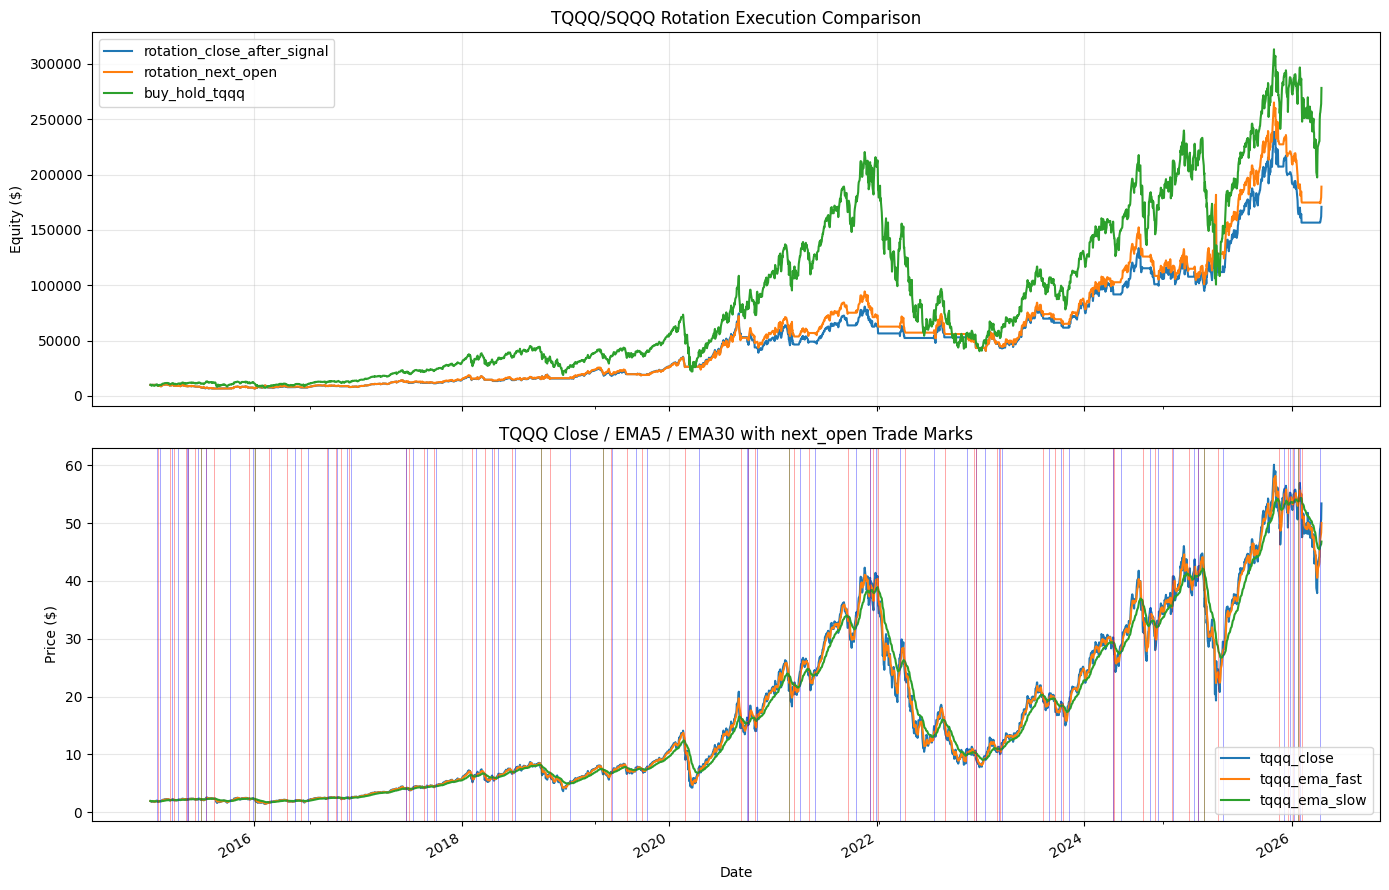

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

plot_df = pd.DataFrame({
    "rotation_close_after_signal": results["close_after_signal"]["strategy_equity"],
    "rotation_next_open": results["next_open"]["strategy_equity"],
    "buy_hold_tqqq": results["next_open"]["buy_hold_tqqq_equity"],
})
plot_df.plot(ax=axes[0])
axes[0].set_title("TQQQ/SQQQ Rotation Execution Comparison")
axes[0].set_ylabel("Equity ($)")
axes[0].grid(True, alpha=0.3)

results["next_open"][["tqqq_close", "tqqq_ema_fast", "tqqq_ema_slow"]].plot(ax=axes[1])
for row in trade_ledger[trade_ledger["execution_mode"] == "next_open"].itertuples(index=False):
    color = "blue" if row.action == "BUY" and row.symbol == "TQQQ" else "red" if row.action == "SELL" else "green"
    axes[1].axvline(row.trade_date, color=color, linewidth=0.7, alpha=0.35)

axes[1].set_title("TQQQ Close / EMA5 / EMA30 with next_open Trade Marks")
axes[1].set_ylabel("Price ($)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
